# vilip1 SAE: run4 (binder-alone) vs. run_paired (co-attention)

Compares two independently-trained SAEs qualitatively: `run4_natural_mix`
(binder-alone activations) and `run_paired` (binder+target-concatenated
activations, via ESM-C's native `|` chain-break token -- see
`sae/pretraining/inference/embed_esmc_paired.py`).

**The linear probe (`cv_r2` vs. binding-quality metrics) was NOT run for
either checkpoint** -- deprioritized for time even after parallelizing
`LassoCV` across 48 cores (see `sae/RESULTS.md`'s "linear probe
deprioritized" note). This notebook is qualitative only: feature density,
max-activating examples, a cross-dictionary consistency check, and
InterPro annotations for a hand-picked feature subset. The co-attention
question (does `run_paired` predict binding affinity better) is **not**
answered here -- nothing in this notebook tests that, only the probe
would have.

Run `training/feature_analysis.py` (no `--probe-metrics-csv`) for each
checkpoint first, on the cluster, to produce the CSVs this notebook reads,
then scp `feature_stats.csv`/`feature_top_examples.csv`/
`interpro_annotations.csv` down into `feature_analysis_run4/` and
`feature_analysis_paired/` at the repo root (gitignored).

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIRS = {
    "run4": "../../feature_analysis_run4",
    "paired": "../../feature_analysis_paired",
}

stats = {name: pd.read_csv(f"{d}/feature_stats.csv") for name, d in RESULTS_DIRS.items()}
top_examples = {name: pd.read_csv(f"{d}/feature_top_examples.csv") for name, d in RESULTS_DIRS.items()}

## Feature density: is each dictionary healthy?

In [2]:
for name, df in stats.items():
    d_hidden = len(df)
    n_dead = int(df["dead"].sum())
    print(f"{name}: {d_hidden} features, {n_dead} dead ({n_dead / d_hidden:.2%})")

run4: 16384 features, 18 dead (0.11%)
paired: 16384 features, 31 dead (0.19%)


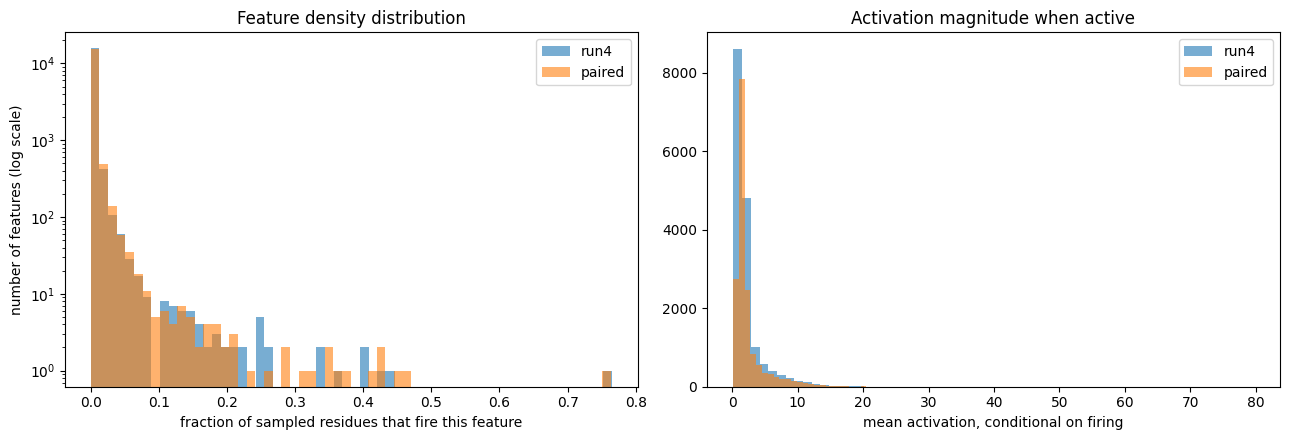

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, df in stats.items():
    alive = df[~df["dead"]]
    axes[0].hist(alive["density"], bins=60, alpha=0.6, label=name)
    axes[1].hist(alive["mean_activation_when_active"], bins=60, alpha=0.6, label=name)
axes[0].set_yscale("log")
axes[0].set_xlabel("fraction of sampled residues that fire this feature")
axes[0].set_ylabel("number of features (log scale)")
axes[0].set_title("Feature density distribution")
axes[0].legend()
axes[1].set_xlabel("mean activation, conditional on firing")
axes[1].set_title("Activation magnitude when active")
axes[1].legend()
plt.tight_layout()

## Max-activating examples: what does a feature detect?

Read the contexts of a feature's top-activating residues (bracketed
residue = the one that fired) and look for a shared pattern.

In [4]:
def show_feature(name: str, feature_id: int, n: int = 10) -> None:
    df = top_examples[name]
    rows = df[df["feature"] == feature_id].sort_values("rank").head(n)
    density = stats[name].loc[stats[name]["feature"] == feature_id, "density"].iloc[0]
    print(f"[{name}] feature {feature_id} (density={density:.4%})")
    for _, r in rows.iterrows():
        print(f"  act={r['activation']:.3f}  {r['source']:>25s}  {r['protein_id']:<28s} pos={r['position']:<5d} {r['context']}")


# most generic feature in each dictionary
for name, df in stats.items():
    top_feat = int(df[~df["dead"]].sort_values("density", ascending=False).iloc[0]["feature"])
    show_feature(name, top_feat, n=5)
    print()

[run4] feature 14247 (density=76.4617%)
  act=31.507      binder_dataset_vilip1  evalbinder_Q9ULV0            pos=1715  MQLRYN[I]SQLEEW
  act=24.841      binder_dataset_vilip1  evalbinder_Q15078            pos=229   AVLLTC[L]YLSYSY
  act=24.482      binder_dataset_vilip1  evalbinder_Q53HL2            pos=42    KQIESD[R]QNLLKE
  act=24.470      binder_dataset_vilip1  evalbinder_Q9UD71            pos=10    DRKKIQ[F]SVPAPP
  act=23.898      binder_dataset_vilip1  evalbinder_Q93050            pos=802   SAFLHA[L]RLHWVE

[paired] feature 582 (density=76.3135%)
  act=36.256      binder_dataset_vilip1  evalbinder_Q9ULV0            pos=1715  MQLRYN[I]SQLEEW
  act=31.169      binder_dataset_vilip1  evalbinder_Q9ULV0            pos=677   KRAVQQ[L]RACGVL
  act=29.531      binder_dataset_vilip1  evalbinder_Q93050            pos=802   SAFLHA[L]RLHWVE
  act=28.550      binder_dataset_vilip1  evalbinder_Q15078            pos=229   AVLLTC[L]YLSYSY
  act=26.848      binder_dataset_vilip1  evalbinder_Q53

## Cross-dictionary consistency check

`run4` and `run_paired` are independently trained SAEs (different data:
binder-alone vs. binder+target). If their most-generic features'
hardest-firing residues land on the *same* (protein, position) more often
than chance, that's real evidence of shared, non-artifactual signal in
the underlying activations -- not just two dictionaries separately
fitting noise. Across millions of candidate residues in the corpus, any
agreement at all is notable.

In [5]:
def top1_hits(name: str, n: int = 30) -> set:
    df, top = stats[name], top_examples[name]
    alive = df[~df["dead"]].sort_values("density", ascending=False).head(n)
    rank0 = top[top["rank"] == 0].set_index("feature")
    hits = set()
    for feat in alive["feature"]:
        if feat in rank0.index:
            r = rank0.loc[feat]
            hits.add((r["protein_id"], int(r["position"])))
    return hits


N_TOP = 30
h4 = top1_hits("run4", N_TOP)
hP = top1_hits("paired", N_TOP)
overlap = h4 & hP
print(f"Top-{N_TOP}-density features, unique (protein,position) top-1 hits: run4={len(h4)}, paired={len(hP)}")
print(f"Overlap: {len(overlap)}")
for pid, pos in sorted(overlap):
    print(f"  {pid} pos={pos}")

Top-30-density features, unique (protein,position) top-1 hits: run4=28, paired=27
Overlap: 6
  Q03692 pos=471
  evalbinder_P49810 pos=364
  evalbinder_Q9ULU8 pos=6
  evalbinder_Q9ULV0 pos=677
  evalbinder_Q9ULV0 pos=1715
  pres_UZJNvRzBCZxzyxex6Dk3 pos=26


## InterPro annotations

Cross-references each example residue's exact position against real
domain/family database hits (EBI InterProScan5), for the hand-picked
feature subset covering: the cross-dictionary overlap hotspots above, plus
the standard density/rare-strong pilot selection from
`FEATURE_LABELING_SETUP.md`. Expect sparse coverage for pure de novo
designs -- a hit at all is informative, not the default.

In [6]:
interpro = {}
for name, d in RESULTS_DIRS.items():
    path = f"{d}/interpro_annotations.csv"
    if os.path.exists(path):
        interpro[name] = pd.read_csv(path)
        n_annotated = interpro[name]["interpro_annotation"].notna().sum()
        print(f"{name}: {len(interpro[name])} rows loaded, {n_annotated} annotated ({n_annotated / len(interpro[name]):.1%})")
    else:
        print(f"{name}: {path} not found yet -- scp it down once fetch_interpro.py finishes")

run4: 165 rows loaded, 131 annotated (79.4%)
paired: ../../feature_analysis_paired/interpro_annotations.csv not found yet -- scp it down once fetch_interpro.py finishes


In [7]:
# Eyeball the actual hits -- don't just trust a coverage percentage, read
# the annotation column itself (per FEATURE_LABELING_SETUP.md's own advice).
for name, df in interpro.items():
    print(f"=== {name} ===")
    annotated = df[df["interpro_annotation"].notna()]
    print(annotated[["feature", "protein_id", "position", "interpro_annotation"]].head(20))
    print()

=== run4 ===
    feature                 protein_id  position  \
15     1707  pres_UZJNvRzBCZxzyxex6Dk3        26   
17     1707          evalbinder_P05067       445   
18     1707          evalbinder_Q96KV7      1501   
21     1707  pres_Pav1HtFIz9ERy3aBrxPw       114   
22     1707  pres_6jOvTKt1gSMNqAjrs2DM        56   
23     1707          evalbinder_Q96KV7       760   
24     1707          evalbinder_Q96KV7      1543   
25     1707          evalbinder_Q8NCB2        81   
27     1707  pres_YOFNLHIuiiO1HyzJGIua       116   
28     1707  pres_JrspHSQMW1wn87BjTLhC        86   
29     1707          evalbinder_P07196       264   
30     2214          evalbinder_P36222       375   
31     2214          evalbinder_P36222       371   
32     2214          evalbinder_P36222       372   
33     2214          evalbinder_P36222       367   
34     2214          evalbinder_P36222       366   
35     2214          evalbinder_P36222       374   
36     2214          evalbinder_P36222       369   

## Takeaways

Fill in after reading the actual output above:

- Dead-feature fraction for each dictionary -- both healthy (<0.2%)?
- Cross-dictionary overlap count -- how many of the top-N generic features
  agree on their single hardest-firing residue between run4 and paired?
- For the overlapping hotspots: do the InterPro hits (if any) explain
  *why* these particular residues are so broadly salient across both
  training distributions?
- Anything qualitatively different between run4's and paired's
  max-activating contexts for the same underlying hotspot positions --
  does adding the target change which residues each dictionary considers
  most salient, even where they agree on others?
- Explicit reminder for whoever reads this next: no `cv_r2`/probe numbers
  here. If there's time before the actual submission, revisit running the
  probe (see `sae/RESULTS.md`) -- that's the only way to answer whether
  co-attention embeddings predict binding affinity better, which was the
  original motivation for training `run_paired` at all.